In [1]:
import pandas as pd

df_rpk = pd.read_csv('All_source_plates_mapped_rpk_column_names_standardized_unique_identifiers_for_duplicates_with_hbdb_plate_samples_dropped_less_100k_readcounts_071426.csv').set_index('peptide')

In [2]:
first_tp = pd.read_csv('earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv').set_index('peptide')

In [3]:
first_tp_sample_ids = first_tp.columns.to_list()

In [4]:
# For C-/H-/S- samples: strip one trailing _N (technical replicate suffix)
# For AG/Canary/mAb: strip ALL trailing _N or _sN segments so they all collapse to their base name
def get_prefix(col):
    if re.match(r'^(AG|Canary|mAb)', col):
        return re.sub(r'(_s?\d+)+$', '', col)
    else:
        return re.sub(r'_\d+$', '', col) #this starts removing from the end of the string, $ means end, \d one or more digits, _ underscore

import re
prefix = df_rpk.columns.map(get_prefix)

In [5]:
df_rpk.columns = df_rpk.columns.map(get_prefix)

In [6]:
df_rpk.head(2)

,C-452-2_5_H3,C-109-3_4_E7,C-109-3_4_E7,C-111-3_3_I6,C-111-3_3_I6,C-112-1_3_B3,C-112-1_3_B3,C-112-2_7_G7,C-112-2_7_G7,C-114-2_7_B1,...,HBDB-109,HBDB-109,HBDB-111,HBDB-111,HBDB-115,HBDB-115,mAb,mAb,mAb,mAb
peptide,,,,,,,,,,,,,,,,,,,,,
WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_1,0.0,0.0,0.0,0.870155,0.0,0.0,0.918952,0.368368,0.000000,0.0,...,0.000000,0.0,0.0,0.255092,0.00000,0.0,0.0,0.0,0.178464,0.59977
WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_2,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.580242,0.0,...,0.214736,0.0,0.0,0.255092,0.68292,0.0,0.0,0.0,0.000000,0.00000


### subset to only first timepoints in cohort

In [7]:
df_rpk_with_techreps_first_tp = df_rpk.loc[:, df_rpk.columns.isin(first_tp_sample_ids)]

In [17]:
import pandas as pd
from itertools import combinations

tech_corr = []

for name in df_rpk_with_techreps_first_tp.columns.unique():
    cols = df_rpk_with_techreps_first_tp.loc[:, df_rpk_with_techreps_first_tp.columns == name]
    if cols.shape[1] > 1:
        for i, j in combinations(range(cols.shape[1]), 2):
            r = cols.iloc[:, i].corr(cols.iloc[:, j])
            tech_corr.append({
                "sample": name,
                "correlation": r
            })

tech_corr = pd.DataFrame(tech_corr)


In [21]:
print(type(tech_corr))

<class 'pandas.core.frame.DataFrame'>


### now calculate pearson correlation between samples (techreps already averaged)

In [9]:
import pandas as pd
from itertools import combinations

nontech_corr_all = []

for sample1, sample2 in combinations(first_tp.columns, 2):
    r = first_tp[sample1].corr(first_tp[sample2], method="pearson")
    nontech_corr_all.append(r)




## Now combine the two dataframes for plotting

In [26]:
import pandas as pd

corr_df = pd.DataFrame({
    "correlation": tech_corr["correlation"].to_list() + nontech_corr_all,
    "group": (
        ["Technical replicates"] * len(tech_corr) +
        ["Between individuals"] * len(nontech_corr_all)
    )
})

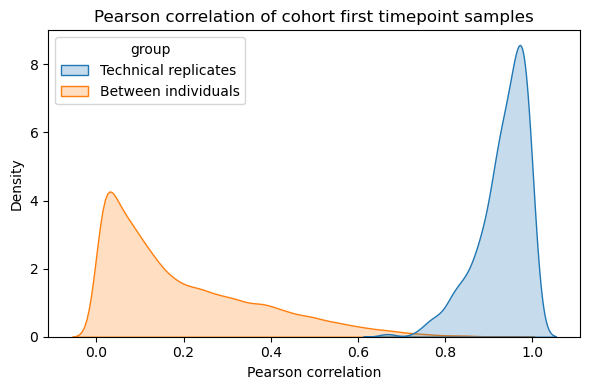

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.kdeplot(
    data=corr_df,
    x="correlation",
    hue="group",
    fill=True,
    common_norm=False
)
plt.xlabel("Pearson correlation")
plt.title("Pearson correlation of cohort first timepoint samples")
plt.tight_layout()
plt.show()